# Visualize Upper Peninsula Hiking Trails

This notebook maps grouped Michigan DNR hiking trails by length category. County shading represents the total trail miles in each Upper Peninsula county.

In [13]:
from pathlib import Path  # File paths

import certifi  # SSL certificates
import requests  # HTTP requests
import pandas as pd  # Tabular data
import geopandas as gpd  # Geospatial data
import matplotlib.pyplot as plt  # Data visualization

## 1. Load and validate grouped trails

Load the processed trail groups and confirm that the fields and geometry required for mapping are valid.

In [14]:
DATA_PATH = Path(
    "../data/processed/dnr_up_hiking_trails_grouped.parquet"
)

trails = gpd.read_parquet(DATA_PATH)

required_trail_columns = [
    "County",
    "TrailLengthMiles",
    "LengthCategory",
    "geometry",
]

missing_trail_columns = [
    column
    for column in required_trail_columns
    if column not in trails.columns
]

if missing_trail_columns:
    raise ValueError(
        f"Missing required trail columns: {missing_trail_columns}"
    )

if trails.empty:
    raise ValueError("The grouped trail dataset is empty.")

if trails.crs is None:
    raise ValueError("The trail dataset does not have a CRS.")

if trails.geometry.isna().any():
    raise ValueError("The trail dataset contains missing geometry.")

if trails.geometry.is_empty.any():
    raise ValueError("The trail dataset contains empty geometry.")

if not trails.geometry.is_valid.all():
    raise ValueError("The trail dataset contains invalid geometry.")

if trails["County"].isna().any():
    raise ValueError("The trail dataset contains missing county values.")

if not pd.api.types.is_numeric_dtype(trails["TrailLengthMiles"]):
    raise TypeError("TrailLengthMiles must be numeric.")

if trails["TrailLengthMiles"].isna().any():
    raise ValueError("The trail dataset contains missing trail lengths.")

if (trails["TrailLengthMiles"] < 0).any():
    raise ValueError("The trail dataset contains negative trail lengths.")

if trails["LengthCategory"].isna().any():
    raise ValueError("The trail dataset contains missing length categories.")

expected_categories = {"Short", "Medium", "Long"}
unexpected_categories = sorted(
    set(trails["LengthCategory"].astype(str)) - expected_categories
)

if unexpected_categories:
    raise ValueError(
        f"Unexpected length categories: {unexpected_categories}"
    )

print(f"Grouped trails: {len(trails):,}")
print(f"Trail counties: {trails['County'].nunique()}")
print(f"Trail CRS: EPSG:{trails.crs.to_epsg()}")


Grouped trails: 159
Trail counties: 15
Trail CRS: EPSG:4326


## 2. Download and validate county boundaries

Retrieve Michigan county polygons and confirm that the required attributes and geometry are present.

In [15]:
COUNTY_QUERY_URL = (
    "https://imagery.michigan.gov/server/rest/services/"
    "CountiesAndMuniBoundaries/MapServer/1/query"
)

query_parameters = {
    "where": "1=1",
    "outFields": "NAME,PENINSULA",
    "returnGeometry": "true",
    "outSR": "4326",
    "f": "geojson",
}

response = requests.get(
    COUNTY_QUERY_URL,
    params=query_parameters,
    timeout=60,
    verify=certifi.where(),
)
response.raise_for_status()

county_geojson = response.json()

if not county_geojson.get("features"):
    raise RuntimeError("The county service returned no features.")

counties = gpd.GeoDataFrame.from_features(
    county_geojson["features"],
    crs="EPSG:4326",
)

required_county_columns = [
    "NAME",
    "PENINSULA",
    "geometry",
]

missing_county_columns = [
    column
    for column in required_county_columns
    if column not in counties.columns
]

if missing_county_columns:
    raise ValueError(
        f"Missing required county columns: {missing_county_columns}"
    )

if counties.empty:
    raise ValueError("The county dataset is empty.")

if counties.crs is None:
    raise ValueError("The county dataset does not have a CRS.")

if counties.geometry.isna().any():
    raise ValueError("The county dataset contains missing geometry.")

if counties.geometry.is_empty.any():
    raise ValueError("The county dataset contains empty geometry.")

if not counties.geometry.is_valid.all():
    raise ValueError("The county dataset contains invalid geometry.")

print(f"Michigan counties: {len(counties):,}")
print(f"County CRS: EPSG:{counties.crs.to_epsg()}")


Michigan counties: 83
County CRS: EPSG:4326


## 3. Prepare Upper Peninsula map layers

Filter the county data to the Upper Peninsula and calculate the total trail miles represented in each county.

In [16]:
up_counties = counties[
    counties["PENINSULA"]
    .astype(str)
    .str.contains("upper", case=False, na=False)
].copy()

if up_counties.empty:
    raise ValueError("No Upper Peninsula counties were found.")

if len(up_counties) != 15:
    raise ValueError(
        f"Expected 15 Upper Peninsula counties, found {len(up_counties)}."
    )

if up_counties.crs != trails.crs:
    up_counties = up_counties.to_crs(trails.crs)

trails = trails.copy()
trails["CountyKey"] = (
    trails["County"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .str.replace(r"\s+county$", "", regex=True)
)

up_counties["CountyKey"] = (
    up_counties["NAME"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .str.replace(r"\s+county$", "", regex=True)
)

county_miles = (
    trails.groupby("CountyKey", as_index=False)["TrailLengthMiles"]
    .sum()
    .rename(columns={"TrailLengthMiles": "CountyTrailMiles"})
)

up_counties = up_counties.merge(
    county_miles,
    on="CountyKey",
    how="left",
    validate="one_to_one",
)

up_outline = up_counties[["geometry"]].dissolve()


## 4. Validate county trail totals

Confirm that trail counties matched the county layer and that the calculated county totals are complete and reasonable.

In [17]:
unmatched_trail_counties = sorted(
    set(county_miles["CountyKey"])
    - set(up_counties["CountyKey"])
)

if unmatched_trail_counties:
    raise ValueError(
        "Trail counties did not match the county layer: "
        f"{unmatched_trail_counties}"
    )

if up_counties["NAME"].duplicated().any():
    raise ValueError("The Upper Peninsula layer contains duplicate counties.")

up_counties["CountyTrailMiles"] = (
    up_counties["CountyTrailMiles"].fillna(0)
)

if (up_counties["CountyTrailMiles"] < 0).any():
    raise ValueError("A county has a negative trail-mile total.")

if not up_counties.geometry.is_valid.all():
    raise ValueError("The Upper Peninsula layer contains invalid geometry.")

if trails.crs != up_counties.crs:
    raise ValueError("The trail and county layers use different CRS values.")

county_summary = up_counties[["NAME", "CountyTrailMiles"]].copy()
county_summary["CountyTrailMiles"] = county_summary["CountyTrailMiles"].round(2)
county_summary = county_summary.sort_values(
    "CountyTrailMiles",
    ascending=False,
)

print(f"UP counties: {len(up_counties)}")
print(f"Total mapped trail miles: {up_counties['CountyTrailMiles'].sum():,.2f}")
county_summary


UP counties: 15
Total mapped trail miles: 1,093.64


,NAME,CountyTrailMiles
11,Marquette,182.85
13,Ontonagon,132.83
10,Mackinac,117.31
0,Alger,113.88
2,Chippewa,101.71
9,Luce,80.01
5,Gogebic,79.19
3,Delta,71.96
14,Schoolcraft,65.23
1,Baraga,60.87


## 5. Map trails and county trail miles

Shade counties by total trail miles and overlay the trail paths by length category.

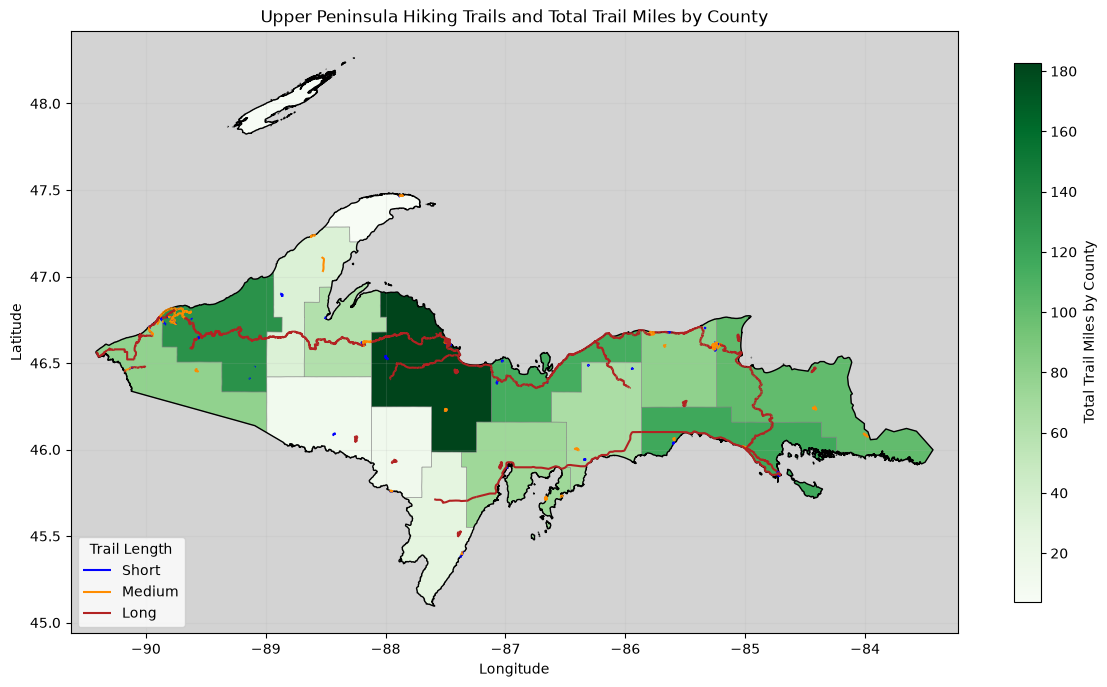

In [18]:
category_colors = {
    "Short": "blue",
    "Medium": "darkorange",
    "Long": "firebrick",
}

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor("lightgray")
ax.grid(False)

up_counties.plot(
    ax=ax,
    column="CountyTrailMiles",
    cmap="Greens",
    edgecolor="none",
    legend=True,
    legend_kwds={
        "label": "Total Trail Miles by County",
        "shrink": 0.7,
        "format": "%.0f",
    },
    zorder=0,
)

up_counties.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=0.35,
    alpha=0.75,
    zorder=1,
)

up_outline.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.0,
    zorder=2,
)

for category, color in category_colors.items():
    category_trails = trails[
        trails["LengthCategory"].astype(str) == category
    ]

    category_trails.plot(
        ax=ax,
        color=color,
        linewidth=1.5,
        label=category,
        zorder=3,
    )

min_x, min_y, max_x, max_y = up_outline.total_bounds
x_padding = (max_x - min_x) * 0.03
y_padding = (max_y - min_y) * 0.05

ax.set_xlim(min_x - x_padding, max_x + x_padding)
ax.set_ylim(min_y - y_padding, max_y + y_padding)
ax.set_title("Upper Peninsula Hiking Trails and Total Trail Miles by County")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Trail Length", loc="lower left")
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()
